In [1]:
# ===========================================================
# BLOCK 0 — Install Required Python Packages
# ===========================================================
# This block installs the libraries we will use throughout the lab.
# You only need to run this once per environment.

# ----------------------
# Install pandas (data tables)
# ----------------------
!python -m pip install pandas --quiet

# ----------------------
# Install matplotlib (plotting)
# ----------------------
import sys
!{sys.executable} -m pip install matplotlib --quiet

# ----------------------
# Install SciPy (statistics + scientific tools)
# ----------------------
import sys
!{sys.executable} -m pip install scipy --quiet

# ----------------------
# Install scikit-learn (machine learning)
# ----------------------
import sys
!{sys.executable} -m pip install scikit-learn --quiet

print("🎉 All required packages are now installed! You're ready for Block 1.")


🎉 All required packages are now installed! You're ready for Block 1.


In [2]:
# ===========================================================
# BLOCK 1 — Load Data and Extract Features
# ===========================================================
# In this block, we load the dataset and separate:
#   • Target values (the values we want to predict: SO, T80, or Photostability)
#   • Feature names (column headers for all descriptors)
#   • Numerical feature matrix (values used for regression)
#
# Columns in your file:
#   Column E (index 3)  → SO values (target 1)
#   Column F (index 4)  → T80 values (target 2)
#   Column G (index 5)  → Photostability values (target 3)
#   Columns H–AY        → chemical features (inputs)
# ===========================================================

import pandas as pd
import numpy as np

# ✏️ STUDENT TASK:
# Make sure the CSV file is in the same folder as your notebook.
# If your file has a different name, change it below:
df = pd.read_csv("OligomerFeatures-condensed.csv")

# Number of molecules with measured SO values. 
molecs = 40  

# -----------------------------------------------------------
# Extract feature names and feature values
# -----------------------------------------------------------
# Columns H through AY correspond to index 7 through 51.
# We use .values[7:51] to get the column NAMES
# and .iloc[:, 7:51] to get the numerical DATA.
# -----------------------------------------------------------

first_feature_col = 7     # H
last_feature_col  = 51    # AY + 1 (Python slices stop BEFORE last)

data_labels = np.array(df.columns.values[first_feature_col:last_feature_col])
all_features = np.array(df.iloc[:molecs, first_feature_col:last_feature_col])

# -----------------------------------------------------------
# Extract target values. These are the target values we want to predict. 
# -----------------------------------------------------------
# ✏️ STUDENT TASK:
# For each notebook, change the target (SO, T80, or Photostability) and target index (3, 4, or 5)
SO = np.array(df.iloc[:molecs, 4])

print("🎉 All required data and features have been loaded! You're ready for Block 2.")

# ❓ Reflection:
# How many features are in your dataset?
# Why is it important to separate the target from the features?


🎉 All required data and features have been loaded! You're ready for Block 2.


In [3]:
# ===========================================================
# BLOCK 2 — Train regression models
# ===========================================================

# In this block, you will define a function that:
#   • Fits a linear regression model using a target property as a function of selected features
#   • Uses the model to predict target values
#   • Calculates R²  → how well the model fits the data aka how much of the variation in y is explained by the model
#   • Calculates adjusted R² → penalizes overly complex models
#
# WHY THIS MATTERS:
# Linear regression finds the “best-fit line” (or plane, or
# hyperplane) through your multidimensional data.
#
# R² and adjusted R² will help you compare the quality of different models throughout the workflow. 
# ===========================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


def evaluate_model(X, y, feature_names):
    """
    INPUTS:
    X  → Feature matrix (rows = molecules, columns = descriptors)

    y  → Target property you want to predict

    """

    # ----------------------------------------------
    # 1. Fit the linear regression model
    # ----------------------------------------------
    model = LinearRegression().fit(X, y)

    # ----------------------------------------------
    # 2. Predict y values using the trained model
    # ----------------------------------------------
    y_pred = model.predict(X)

    # ----------------------------------------------
    # 3. Compute R² (goodness of fit)
    # ----------------------------------------------
    r2 = r2_score(y, y_pred)

    # ----------------------------------------------
    # 4. Compute adjusted R²
    #    Formula penalizes excessive numbers of features.
    # ----------------------------------------------
    adj_r2 = 1 - (1 - r2) * (len(y) - 1) / (len(y) - X.shape[1] - 1)

    # ----------------------------------------------
    # 5. Return results in a tidy structure
    # ----------------------------------------------
    return {
        "features": feature_names,
        "model": model,
        "r2": r2,
        "adj_r2": adj_r2
    }

print("🎉 Linear regression models have been trained! You're ready for Block 3.")

🎉 Linear regression models have been trained! You're ready for Block 3.


In [4]:
# ===========================================================
# BLOCK 3 — Model Evaluation Settings
# ===========================================================

# In this block, you will perform **univariate linear regression** on
# every descriptor individually. It answers the question:
#     “How well does each feature, by itself, explain the target?”
#
# WHY STUDENTS DO THIS:
# - Helps identify which descriptors correlate strongly with the property
# - Provides intuition before moving to multivariate modeling
# - Shows that not all features contribute equally
#
# WHAT THE FUNCTION RETURNS:
# A list of the top k model results (sorted by |R²|)
#
# ------------------------------------------------------------


from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


def evaluate_model(X, y, feature_names):
    """
    Fits a linear regression model and reports performance.

    PARAMETERS:
    -------------------------------------------------------
    X : 2D array
        Feature matrix (rows = molecules, columns = descriptors)

    y : 1D array
        Target property you want to predict

    feature_names : list of strings
        Names of the descriptors used in this model

    RETURNS:
    -------------------------------------------------------
    A dictionary with:
        "model"     → trained LinearRegression model
        "features"  → list of feature names used
        "r2"        → coefficient of determination (0–1 scale)
        "adj_r2"    → adjusted R² (accounts for # of features)

    HOW IT WORKS:
    -------------------------------------------------------
    • R² measures how much of the variation in y the model
      can explain. Higher is usually better.
    • Adjusted R² penalizes a model if too many features are
      added without improving the fit.
    """

    # -------------------------------------------------------
    # 1. Fit a linear regression model to the provided data
    # -------------------------------------------------------
    model = LinearRegression().fit(X, y)

    # -------------------------------------------------------
    # 2. Predict y values using the trained model
    # -------------------------------------------------------
    y_pred = model.predict(X)

    # -------------------------------------------------------
    # 3. Compute standard R²
    # -------------------------------------------------------
    r2 = r2_score(y, y_pred)

    # -------------------------------------------------------
    # 4. Compute Adjusted R²
    #    This rewards models that explain variation efficiently. 
    #    Adjusted R² helps you pick the model that truly performs better, 
    #    not the one that just uses more variables.
    # -------------------------------------------------------
    adj_r2 = 1 - (1 - r2) * (len(y) - 1) / (len(y) - X.shape[1] - 1)

    # -------------------------------------------------------
    # 5. Package everything into a single structure
    # -------------------------------------------------------
    return {
        "features": feature_names,
        "model": model,
        "r2": r2,
        "adj_r2": adj_r2
    }

# ❓ Reflection:
# Why do we need adjusted R² when comparing models with different numbers of features??
# Can adding more descriptors ever make a model worse? Why?

print("🎉 Model evaluation function loaded. Proceed to Block 4 to run regressions!")

🎉 Model evaluation function loaded. Proceed to Block 4 to run regressions!


In [5]:
# ===========================================================
# BLOCK 4 — Univariate Regression and Selecting Top Features
# ===========================================================
# In this block, you will:
#   • Evaluate each feature individually using linear regression
#   • Compute R² and adjusted R² for each feature
#   • Identify the top k features that best correlate with the target
#
# Why we do this:
#   • Helps quickly see which descriptors are most informative
#   • Reduces the number of features for subsequent multivariate regression (reduce computational time)
# ===========================================================

import pandas as pd

def univariate_top_k(X, y, labels, k=30):
    """
    INPUTS:
    X      → Feature matrix (rows = molecules, columns = descriptors)
    y      → Target property
    labels → List of feature names corresponding to columns in X
    k      → Number of top features to return (default = 30)

    RETURNS:
    top_k  → List of dictionaries containing top k feature models
    report → Pandas DataFrame tabulating R² and adjusted R² for top k features
    """

    results = []
    for i, lab in enumerate(labels):
        # Extract single feature as 2D array
        Xi = X[:, i].reshape(-1, 1)
        # Evaluate a linear regression for this feature
        res = evaluate_model(Xi, y, [lab])
        results.append(res)

    # Sort features by absolute R² (strongest correlations first)
    results = sorted(results, key=lambda x: abs(x["r2"]), reverse=True)
    top_k = results[:k]

    # Create a nice table to inspect
    report = pd.DataFrame({
        "Feature": [m["features"][0] for m in top_k],
        "R2": [round(m["r2"], 3) for m in top_k],
        "Adjusted R2": [round(m["adj_r2"], 3) for m in top_k]
    })

    return top_k, report
print("🎉 Univariate regression complete. Top features are tabulated. Proceed to Block 5 to run multivariable regressions!")

# -----------------------------------------------------------
# Run univariate regression and select top 30 features
# -----------------------------------------------------------
top_uni, uni_report = univariate_top_k(all_features, SO, data_labels, k=30)
selected_features = [m["features"][0] for m in top_uni]

# Display the results as a visually appealing table in Jupyter
uni_report.style.background_gradient(cmap='Blues')


🎉 Univariate regression complete. Top features are tabulated. Proceed to Block 5 to run multivariable regressions!


,Feature,R2,Adjusted R2
0,TDOS2.4,0.419000,0.404000
1,TDOS2.5,0.397000,0.381000
2,TDOS2.3,0.270000,0.251000
3,T4,0.193000,0.171000
4,Rg,0.175000,0.153000
5,HAcceptors,0.169000,0.147000
6,TDOS2.6,0.160000,0.138000
7,TDOS2.2,0.136000,0.113000
8,NumHeteroatoms,0.111000,0.088000
9,LUMOp1(eV),0.061000,0.036000


In [6]:
# ===========================================================
# BLOCK 5 — Multivariate Regression
# ===========================================================
# In this block, you will:
#   • Evaluate combinations of features (2, 3, or 4 at a time)
#   • Fit linear regression models for each combination
#   • Rank models by adjusted R² to find the most predictive feature sets
#   • Display the top k models in a clean, tabulated form
#
# WHY THIS MATTERS:
#   • Demonstrates how adding more features affects model performance
#   • Highlights interactions between descriptors that are more informative together
# ===========================================================

from itertools import combinations
from IPython.display import display

def multivariate_top_k(X, y, labels, selected_labels, n_vars=2, k=5):
    """
    INPUTS:
    X               → Full feature matrix
    y               → Target property (SO)
    labels          → Names of all features in X
    selected_labels → Subset of features to consider (from univariate step)
    n_vars          → Number of features per combination (2,3,4)
    k               → Number of top models to report

    RETURNS:
    top_k → List of dictionaries with top models
    report → Pandas DataFrame showing features, R², and adjusted R²
    """
    # Convert feature names to their column indices
    indices = [np.where(labels == lab)[0][0] for lab in selected_labels]
    results = []

    # Generate all combinations of n_vars features
    for combo in combinations(indices, n_vars):
        Xsub = X[:, combo]
        labs = labels[list(combo)]
        res = evaluate_model(Xsub, y, labs)
        results.append(res)

    # Sort by adjusted R² (highest first)
    results = sorted(results, key=lambda x: x["adj_r2"], reverse=True)
    top_k = results[:k]

    # Create a table for display
    report = pd.DataFrame({
        "Features": [", ".join(m["features"]) for m in top_k],
        "R2": [round(m["r2"], 3) for m in top_k],
        "Adjusted R2": [round(m["adj_r2"], 3) for m in top_k]
    })

    return top_k, report

# -----------------------------------------------------------
# Run multivariate models
# -----------------------------------------------------------

# ✏️ STUDENT TASK:
# For each model, change the target (SO, T80, or Photostability)

# Bivariate (2-feature) models
top_bi, bi_report = multivariate_top_k(all_features, SO, data_labels,
                                       selected_features, n_vars=2, k=5)

# Trivariate (3-feature) models
top_tri, tri_report = multivariate_top_k(all_features, SO, data_labels,
                                         selected_features, n_vars=3, k=5)

# Tetravariate (4-feature) models
top_tetra, tetra_report = multivariate_top_k(all_features, SO, data_labels,
                                             selected_features, n_vars=4, k=5)

print("🎉 Multivariate regression complete. Top models are tabulated. Proceed to Block 6 to visualize best models!")


# -----------------------------------------------------------
# Display tables with visual gradients and print headings
# -----------------------------------------------------------

print("🎉 Top 5 Bivariate Models")
display(bi_report.style.background_gradient(cmap='Blues'))

print("🎉 Top 5 Trivariate Models")
display(tri_report.style.background_gradient(cmap='Greens'))

print("🎉 Top 5 Tetravariate Models")
display(tetra_report.style.background_gradient(cmap='Purples'))

# -----------------------------------------------------------
# ✅ Student Reflection Questions
# -----------------------------------------------------------
# 1. How does adding a second or third feature affect R²?
# 2. How does adjusted R² typically compare to R²?
# 3. Do you notice any descriptors that appear repeatedly in the top models? 



🎉 Multivariate regression complete. Top models are tabulated. Proceed to Block 6 to visualize best models!
🎉 Top 5 Bivariate Models


,Features,R2,Adjusted R2
0,"TDOS2.3, TDOS2.2",0.532000,0.506000
1,"TDOS2.3, TDOS2.1",0.529000,0.503000
2,"TDOS2.4, Rg",0.516000,0.490000
3,"TDOS2.3, TDOS2.0",0.515000,0.489000
4,"TDOS2.4, TDOS2.0",0.512000,0.485000


🎉 Top 5 Trivariate Models


,Features,R2,Adjusted R2
0,"TDOS2.5, Rg, TDOS2.7",0.602000,0.569000
1,"TDOS2.4, Rg, Mass",0.600000,0.566000
2,"TDOS2.3, Rg, TDOS2.2",0.596000,0.562000
3,"TDOS2.5, Rg, TDOS2.6",0.590000,0.556000
4,"TDOS2.3, Rg, TDOS2.1",0.587000,0.553000


🎉 Top 5 Tetravariate Models


,Features,R2,Adjusted R2
0,"TDOS2.3, Rg, TDOS2.2, Mass",0.634000,0.593000
1,"TDOS2.3, TDOS2.2, HOMOm1(eV), DipoleMoment(Debye)",0.634000,0.592000
2,"TDOS2.4, Rg, Mass, TDOS3.3",0.633000,0.591000
3,"TDOS2.3, Rg, TDOS2.2, DipoleMoment(Debye)",0.631000,0.589000
4,"TDOS2.3, Rg, TDOS2.2, TDOS3.3",0.631000,0.589000


🎉 Visualization complete. Proceed to Block 7 to get equations for top models!
📈 Plotting Best Univariate Model...


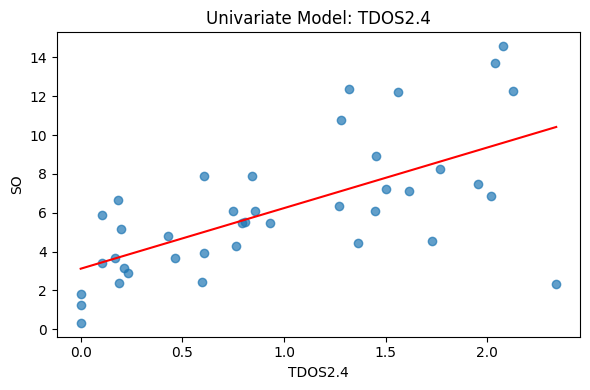

📈 Plotting Best Bivariate Model...


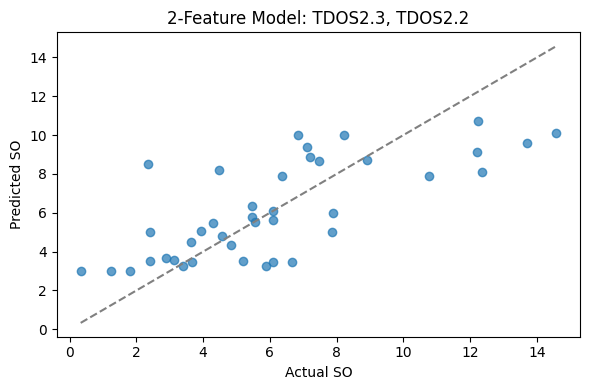

📈 Plotting Best Trivariate Model...


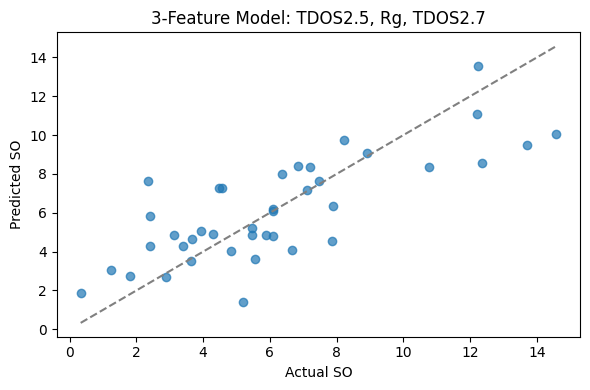

📈 Plotting Best Tetravariate Model...


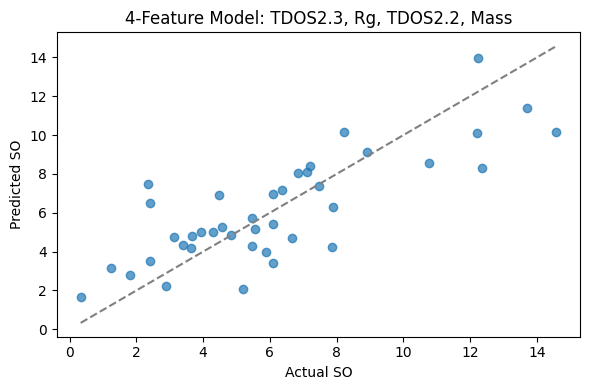

In [11]:
# ===========================================================
# BLOCK 6 — Visualize Top Models
# ===========================================================
# In this block, you will:
#   • Plot the best univariate model (scatter plot + regression line)
#   • Plot the best bivariate, trivariate, and tetravariate models
#       using predicted vs. actual target values
#
# WHY THIS MATTERS:
#   • Visualization helps you *see* model performance
#   • Predicted vs. actual plots reveal:
#         – underfitting (points widely scattered)
#         – overfitting (high R² but poor visual alignment)
#         – systematic error (curved or biased deviations)
#   • Reinforces interpretation of R² and adjusted R²
# ===========================================================

import matplotlib.pyplot as plt

def plot_model(model_info, X, y, labels):
    """
    Plot either:
        • Univariate regression (scatter plot + best-fit line)
        • Multivariate regression (predicted vs actual)
    depending on the number of features in the model.
    """

    model = model_info["model"]
    feature_names = model_info["features"]

    # -------------------------------------------------------
    # Case 1: Univariate model → scatter + regression line
    # -------------------------------------------------------
    if len(feature_names) == 1:
        idx = np.where(labels == feature_names[0])[0][0]
        Xi = X[:, idx]

        plt.figure(figsize=(6, 4))
        plt.scatter(Xi, y, alpha=0.7)

        # Regression line
        xline = np.linspace(min(Xi), max(Xi), 200).reshape(-1, 1)
        yline = model.predict(xline)
        plt.plot(xline, yline, color='red')

        plt.xlabel(feature_names[0])
        # ✏️ STUDENT TASK:
        # For each model, change the target (SO, T80, or Photostability)
        plt.ylabel("SO")
        plt.title(f"Univariate Model: {feature_names[0]}")
        plt.tight_layout()
        plt.show()
        return

    # -------------------------------------------------------
    # Case 2: Multivariate model → predicted vs actual plot
    # -------------------------------------------------------
    col_indices = [np.where(labels == n)[0][0] for n in feature_names]
    Xsub = X[:, col_indices]
    y_pred = model.predict(Xsub)

    plt.figure(figsize=(6, 4))
    plt.scatter(y, y_pred, alpha=0.7)
    plt.plot([min(y), max(y)], [min(y), max(y)], color='gray', linestyle='--')

    # ✏️ STUDENT TASK:
    # For each model, change the target (SO, T80, or Photostability)
    plt.xlabel("Actual SO")
    plt.ylabel("Predicted SO")
    plt.title(f"{len(feature_names)}-Feature Model: {', '.join(feature_names)}")
    plt.tight_layout()
    plt.show()
print("🎉 Visualization complete. Proceed to Block 7 to get equations for top models!")

# -----------------------------------------------------------
# Visualize the top models from each category
# -----------------------------------------------------------

# ✏️ STUDENT TASK:
# For each model, change the target (SO, T80, or Photostability)
print("📈 Plotting Best Univariate Model...")
plot_model(top_uni[0], all_features, SO, data_labels)

print("📈 Plotting Best Bivariate Model...")
plot_model(top_bi[0], all_features, SO, data_labels)

print("📈 Plotting Best Trivariate Model...")
plot_model(top_tri[0], all_features, SO, data_labels)

print("📈 Plotting Best Tetravariate Model...")
plot_model(top_tetra[0], all_features, SO, data_labels)

# -----------------------------------------------------------
# Student Reflection Questions
# -----------------------------------------------------------
#
# 1. For multivariate models:
#       How close are the points to the diagonal y = x line?
#
# 2. Which model seems to visually perform best?
#       Does this match the R² and adjusted R² values from earlier?
# -----------------------------------------------------------


In [13]:
# ===========================================================
# BLOCK 7 — Extract Linear Model Equations & Interpret Coefficients
# ===========================================================
# In this block, you will:
#   • Print the linear regression equation for each top model
#   • Display its coefficients in a table
#   • Highlight the most influential descriptor
#
# WHY THIS MATTERS:
#   • The sign (+/–) of a coefficient tells you whether a feature
#     increases or decreases target.
#   • The magnitude of a coefficient tells you *how strongly*
#     the feature impacts the target (in this linear approximation).
# ===========================================================

import pandas as pd

def print_model_equation_with_highlight(model_info):
    """
    Produce:
        1) A human-readable linear equation
        2) A styled coefficient table with the most important feature highlighted
    """

    model = model_info["model"]
    features = model_info["features"]
    coefs = model.coef_
    intercept = model.intercept_
    
    # -------------------------------------------------------
    # Build a readable linear equation
    # -------------------------------------------------------
    # ✏️ STUDENT TASK:
    # For each model, change the target (SO, T80, or Photostability)
    terms = [f"{round(coef, 3)}*{name}" for coef, name in zip(coefs, features)]
    equation = f"SO = {round(intercept, 3)} + " + " + ".join(terms)
    
    # -------------------------------------------------------
    # Coefficient table: rank by absolute magnitude
    # -------------------------------------------------------
    coef_table = pd.DataFrame({
        "Feature": features,
        "Coefficient": [round(c, 3) for c in coefs],
        "Absolute Value": [abs(round(c, 3)) for c in coefs]
    }).sort_values(by="Absolute Value", ascending=False).reset_index(drop=True)
    
    # Highlight strongest descriptor
    styled_table = coef_table.style.background_gradient(
        cmap='Oranges',
        subset=['Absolute Value']
    ).format({"Coefficient": "{:.3f}", "Absolute Value": "{:.3f}"})
    
    return equation, styled_table


# ===========================================================
#   Print & interpret equations for each top model
# ===========================================================

# ---- Univariate ----
eq_uni, coefs_uni = print_model_equation_with_highlight(top_uni[0])
print("📘 Univariate Model Equation:")
print(eq_uni)
display(coefs_uni)

# ---- Bivariate ----
eq_bi, coefs_bi = print_model_equation_with_highlight(top_bi[0])
print("\n📗 Bivariate Model Equation:")
print(eq_bi)
display(coefs_bi)

# ---- Trivariate ----
eq_tri, coefs_tri = print_model_equation_with_highlight(top_tri[0])
print("\n📙 Trivariate Model Equation:")
print(eq_tri)
display(coefs_tri)

# ---- Tetravariate ----
eq_tetra, coefs_tetra = print_model_equation_with_highlight(top_tetra[0])
print("\n📕 Tetravariate Model Equation:")
print(eq_tetra)
display(coefs_tetra)

# -----------------------------------------------------------
# Student Reflection Questions
# -----------------------------------------------------------
# 1. Look at the sign of each coefficient:
#       Which descriptors increase target? Which decrease it?
#
# 2. Which descriptor has the largest absolute coefficient? Is it the same descriptor in all models? 
#
# 3. Compare univariate vs. multivariate models:
#       Do coefficients change when we add more descriptors?
#       What does this tell you about feature interactions?
#
# 4. In the multivariate models:
#       Are any coefficients surprisingly small? What might this suggest?
# -----------------------------------------------------------

print("🎉 All model equations generated! You have completed the analysis workflow.")



📘 Univariate Model Equation:
SO = 3.12 + 3.12*TDOS2.4


,Feature,Coefficient,Absolute Value
0,TDOS2.4,3.120,3.120



📗 Bivariate Model Equation:
SO = 3.0 + 11.788*TDOS2.3 + -11.218*TDOS2.2


,Feature,Coefficient,Absolute Value
0,TDOS2.3,11.788,11.788
1,TDOS2.2,-11.218,11.218



📙 Trivariate Model Equation:
SO = -2.619 + 3.931*TDOS2.5 + 1.092*Rg + -1.806*TDOS2.7


,Feature,Coefficient,Absolute Value
0,TDOS2.5,3.931,3.931
1,TDOS2.7,-1.806,1.806
2,Rg,1.092,1.092



📕 Tetravariate Model Equation:
SO = -2.645 + 9.343*TDOS2.3 + 1.641*Rg + -8.201*TDOS2.2 + -0.007*Mass


,Feature,Coefficient,Absolute Value
0,TDOS2.3,9.343,9.343
1,TDOS2.2,-8.201,8.201
2,Rg,1.641,1.641
3,Mass,-0.007,0.007


🎉 All model equations generated! You have completed the analysis workflow.
